# Cross-entropy and integrals from scratch

This notebook rebuilds Section 5.7 of [Chapter 5: Loss functions](../chapter-05-loss-functions.pdf) for a learner who has not studied integrals, entropy, KL divergence, or Dirac delta functions.

Unlike the previous version, this is a genuine tour **through the integral notation**, not around it. We will build the required ideas in this order:

$$
\text{area}
\rightarrow \text{rectangle sums}
\rightarrow \text{definite integrals}
\rightarrow \text{probability density}
\rightarrow \text{weighted averages}
\rightarrow \text{entropy and cross-entropy}
\rightarrow \text{Dirac selector spikes}
\rightarrow \text{Equations 5.27--5.31}.
$$

No prior calculus is assumed. Every symbol will be defined before it is used.


## Topic 0 — Orientation


### 0.1 What Section 5.7 is trying to prove

The section compares two descriptions of the targets:

- $q(y)$ describes where the real training targets occur.
- $p(y)$ describes where the model expects targets to occur.

Cross-entropy measures the model's average negative-log score at locations emphasized by the real data.

When $q$ is constructed from the actual training examples, this average becomes

$$
-\frac{1}{I}\sum_{i=1}^{I}\log p(y_i),
$$

which is average negative log-likelihood. Section 5.7 uses integrals and Dirac delta functions to prove this result for continuous targets.


### 0.2 Symbols we will build toward

Do not try to understand this expression yet:

$$
-\int_{-\infty}^{\infty}q(y)\log p(y)\,dy.
$$

By the end, every part will have a plain-language meaning:

| Symbol | Final meaning |
|---|---|
| $y$ | A possible target value |
| $p(y)$ | Model probability density near $y$ |
| $q(y)$ | Real-data density or empirical distribution near $y$ |
| $-\log p(y)$ | Model surprise at $y$ |
| $q(y)[-\log p(y)]$ | Surprise weighted by how much real data occur near $y$ |
| $\int$ | Add these weighted contributions continuously |
| $dy$ | Accumulate along the $y$ axis using tiny widths |


## Topic 1 — Build the definite integral from area


### 1.1 A function gives a height at every horizontal position

Consider

$$
g(y)=y^2.
$$

For every horizontal input $y$, the function provides a vertical height $g(y)$:

| $y$ | $g(y)=y^2$ |
|---:|---:|
| $0$ | $0$ |
| $0.5$ | $0.25$ |
| $1$ | $1$ |
| $2$ | $4$ |

A graph draws all these input–height pairs. A definite integral asks for the accumulated signed area between that graph and the horizontal axis over a chosen interval.


### 1.2 Begin with rectangle area

The area of one rectangle is

$$
\text{area}=\text{width}\times\text{height}.
$$

To estimate area under a curved graph from $a$ to $b$:

1. Divide the interval into $N$ narrow pieces.
2. Give every piece width

$$
\Delta y=\frac{b-a}{N}.
$$

3. Choose a representative point $y_j$ in piece $j$.
4. Use height $g(y_j)$.
5. Add all rectangle areas:

$$
\sum_{j=1}^{N}g(y_j)\Delta y.
$$

The sum is approximate because rectangles do not perfectly follow a curve.


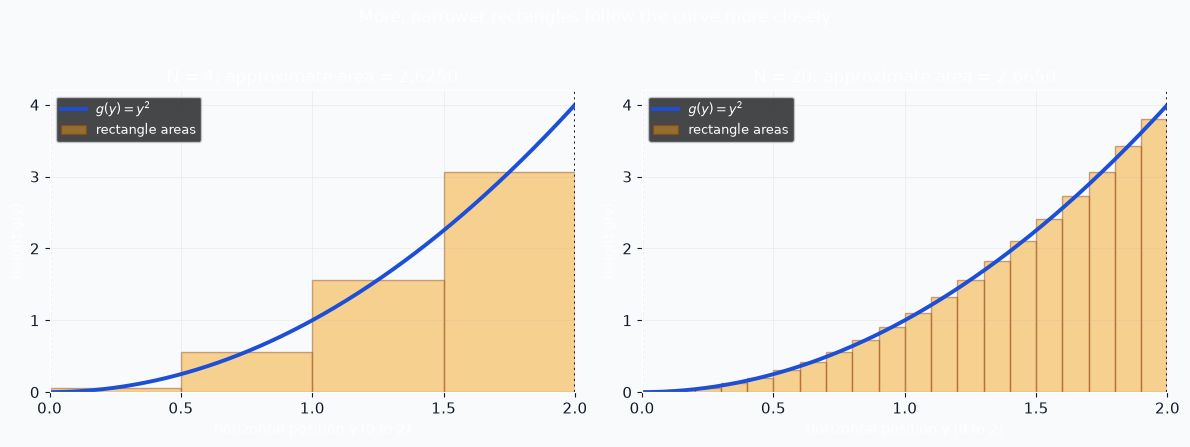

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def draw_rectangles(ax, n_rectangles):
    a, b = 0.0, 2.0
    edges = np.linspace(a, b, n_rectangles + 1)
    width = (b - a) / n_rectangles
    midpoints = edges[:-1] + width / 2
    heights = midpoints**2
    y = np.linspace(a, b, 500)
    ax.plot(y, y**2, color="#1d4ed8", linewidth=2.8, label=r"$g(y)=y^2$")
    ax.bar(midpoints, heights, width=width, alpha=0.45, color="#f59e0b",
           edgecolor="#92400e", align="center", label="rectangle areas")
    approximation = np.sum(heights * width)
    ax.set(title=f"N = {n_rectangles}: approximate area = {approximation:.4f}",
           xlabel="horizontal position y (0 to 2)", ylabel="height g(y)",
           xlim=(0, 2), ylim=(0, 4.2))
    ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])
    ax.set_yticks([0, 1, 2, 3, 4])
    ax.tick_params(axis="both", labelsize=11, colors="#111827")
    ax.axvline(0, color="#111827", linestyle=":", linewidth=1.5)
    ax.axvline(2, color="#111827", linestyle=":", linewidth=1.5)
    ax.legend(fontsize=9); ax.grid(alpha=0.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), facecolor="#f8fafc")
for ax in axes: ax.set_facecolor("#f8fafc")
draw_rectangles(axes[0], 4)
draw_rectangles(axes[1], 20)
fig.suptitle("More, narrower rectangles follow the curve more closely", y=1.03)
fig.tight_layout()
plt.show()


### 1.3 The integral is the limiting rectangle sum

As $N$ increases:

- the width $\Delta y$ becomes smaller;
- there are more rectangles;
- the rectangle sum approaches the exact accumulated area.

The definite integral is defined as this limiting process:

$$
\int_a^b g(y)\,dy
=\lim_{N\rightarrow\infty}
\sum_{j=1}^{N}g(y_j)\Delta y.
$$

Read it as:

> Accumulate the height $g(y)$ from $y=a$ to $y=b$ using infinitely narrow pieces.

You do not need formal limit calculations for Chapter 5. The rectangle picture is the essential meaning.


### 1.4 How to read every part of a definite integral

Consider

$$
\int_a^b g(y)\,dy.
$$

| Part | Name | Meaning |
|---|---|---|
| $\int$ | Integral sign | Continuous accumulation |
| $a$ | Lower bound | Where accumulation starts |
| $b$ | Upper bound | Where accumulation stops |
| $g(y)$ | Integrand | Height or contribution being accumulated |
| $dy$ | Differential | Accumulate with respect to $y$ using tiny widths |

The product-like idea inside the integral is

$$
\text{tiny contribution}
\approx g(y)\times\text{tiny width }dy.
$$

The integral adds all tiny contributions.


### 1.5 Two integrals whose areas are visible

A constant-height rectangle:

$$
\int_0^2 3\,dy=2\times3=6.
$$

A straight line $g(y)=y$ from $0$ to $2$ forms a triangle with base $2$ and height $2$:

$$
\int_0^2 y\,dy
=\frac{1}{2}\times2\times2
=2.
$$

These examples show that a definite integral returns one accumulated number.

In Section 5.7, the integrand is not merely a geometric height. It is a **weighted model surprise**, but the accumulation idea is identical.


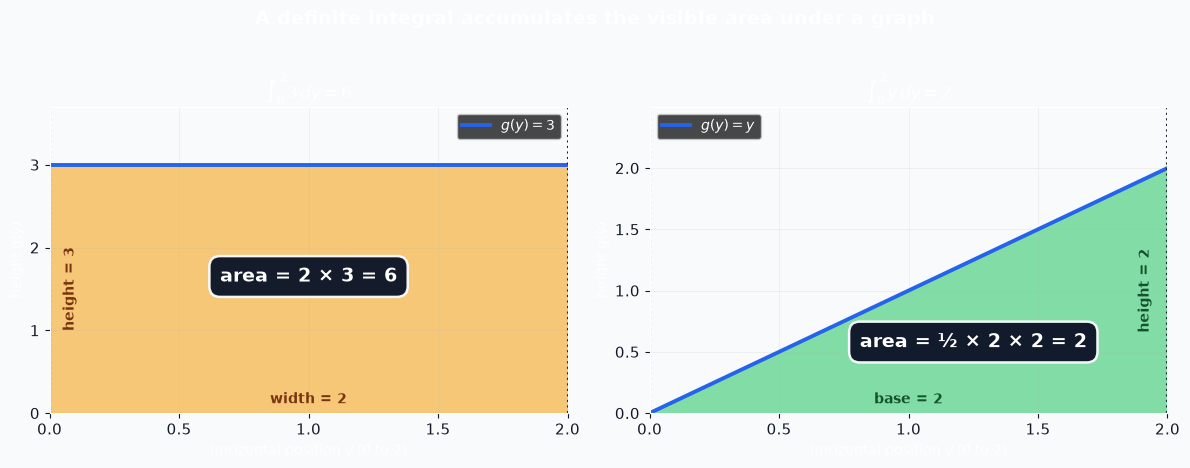

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor="#f8fafc")
for ax in axes:
    ax.set_facecolor("#f8fafc")
    ax.grid(alpha=0.2)

# Integral 1: constant height g(y) = 3 from y = 0 to y = 2.
y_constant = np.linspace(0, 2, 300)
axes[0].plot(y_constant, np.full_like(y_constant, 3), color="#2563eb", linewidth=2.8,
             label=r"$g(y)=3$")
axes[0].fill_between(y_constant, 0, 3, color="#f59e0b", alpha=0.55)
axes[0].annotate("width = 2", xy=(1, 0.12), ha="center", color="#78350f", fontweight="bold")
axes[0].annotate("height = 3", xy=(0.05, 1.5), rotation=90, va="center",
                 color="#78350f", fontweight="bold")
axes[0].text(1, 1.65, "area = 2 × 3 = 6",
             ha="center", va="center", fontsize=14, color="white", fontweight="bold",
             bbox={"boxstyle": "round,pad=0.55", "facecolor": "#0f172a",
                   "edgecolor": "#f8fafc", "linewidth": 1.8, "alpha": 0.98})
axes[0].set(xlim=(0, 2), ylim=(0, 3.7), xlabel="horizontal position y (0 to 2)",
            ylabel="height g(y)", title=r"$\int_0^2 3\,dy=6$")
axes[0].set_xticks([0, 0.5, 1.0, 1.5, 2.0])
axes[0].set_yticks([0, 1, 2, 3])
axes[0].tick_params(axis="both", labelsize=11, colors="#111827")
axes[0].axvline(0, color="#111827", linestyle=":", linewidth=1.5)
axes[0].axvline(2, color="#111827", linestyle=":", linewidth=1.5)
axes[0].legend(loc="upper right")

# Integral 2: line g(y) = y from y = 0 to y = 2.
y_line = np.linspace(0, 2, 300)
axes[1].plot(y_line, y_line, color="#2563eb", linewidth=2.8, label=r"$g(y)=y$")
axes[1].fill_between(y_line, 0, y_line, color="#22c55e", alpha=0.55)
axes[1].annotate("base = 2", xy=(1, 0.08), ha="center", color="#14532d", fontweight="bold")
axes[1].annotate("height = 2", xy=(1.94, 1), rotation=90, va="center", ha="right",
                 color="#14532d", fontweight="bold")
axes[1].text(1.25, 0.58, "area = ½ × 2 × 2 = 2",
             ha="center", va="center", fontsize=14, color="white", fontweight="bold",
             bbox={"boxstyle": "round,pad=0.55", "facecolor": "#0f172a",
                   "edgecolor": "#f8fafc", "linewidth": 1.8, "alpha": 0.98})
axes[1].set(xlim=(0, 2), ylim=(0, 2.5), xlabel="horizontal position y (0 to 2)",
            ylabel="height g(y)", title=r"$\int_0^2 y\,dy=2$")
axes[1].set_xticks([0, 0.5, 1.0, 1.5, 2.0])
axes[1].set_yticks([0, 0.5, 1.0, 1.5, 2.0])
axes[1].tick_params(axis="both", labelsize=11, colors="#111827")
axes[1].axvline(0, color="#111827", linestyle=":", linewidth=1.5)
axes[1].axvline(2, color="#111827", linestyle=":", linewidth=1.5)
axes[1].legend(loc="upper left")

fig.suptitle("A definite integral accumulates the visible area under a graph", y=1.03,
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


### 1.6 Numerical calculation: four rectangles under $g(y)=y^2$

Now calculate a curved example using actual numbers:

$$
\int_0^2 y^2\,dy.
$$

We first approximate it with four equal-width rectangles.

**Step 1 — Calculate each width.**

$$
\Delta y=\frac{2-0}{4}=0.5.
$$

**Step 2 — Choose the midpoint of each interval.**

The intervals are $[0,0.5]$, $[0.5,1]$, $[1,1.5]$, and $[1.5,2]$. Their midpoints are

$$
0.25,\quad 0.75,\quad 1.25,\quad 1.75.
$$

**Step 3 — Evaluate the height $g(y)=y^2$ at each midpoint.**

| Rectangle | Midpoint $y_j$ | Height $g(y_j)=y_j^2$ | Width $\Delta y$ | Rectangle area $g(y_j)\Delta y$ |
|---:|---:|---:|---:|---:|
| 1 | $0.25$ | $0.0625$ | $0.5$ | $0.03125$ |
| 2 | $0.75$ | $0.5625$ | $0.5$ | $0.28125$ |
| 3 | $1.25$ | $1.5625$ | $0.5$ | $0.78125$ |
| 4 | $1.75$ | $3.0625$ | $0.5$ | $1.53125$ |

**Step 4 — Add the four rectangle areas.**

$$
0.03125+0.28125+0.78125+1.53125=2.625.
$$

Therefore,

$$
\int_0^2 y^2\,dy\approx2.625
\qquad\text{using four midpoint rectangles.}
$$

This is an approximation. More, narrower rectangles move the answer toward the exact value.


rectangle   midpoint   height y²   width   rectangle area
        1       0.25      0.0625    0.50          0.03125
        2       0.75      0.5625    0.50          0.28125
        3       1.25      1.5625    0.50          0.78125
        4       1.75      3.0625    0.50          1.53125

Four-rectangle sum = 2.62500
Exact integral      = 2.66667


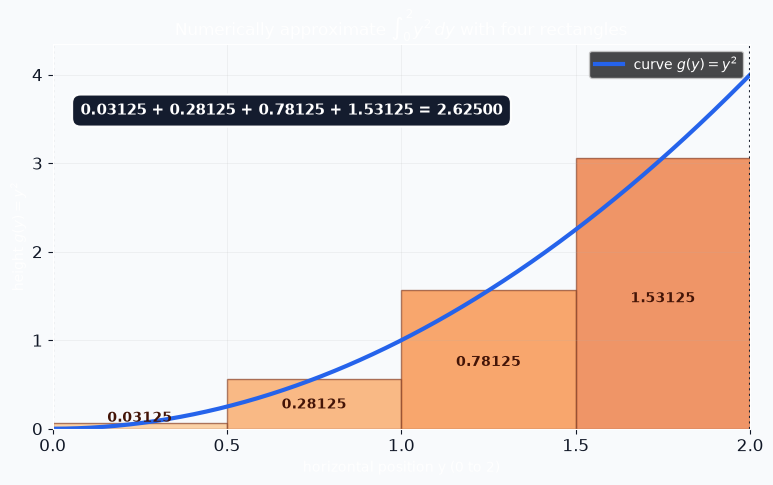

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Four midpoint rectangles on [0, 2].
a, b, number_of_rectangles = 0.0, 2.0, 4
width = (b - a) / number_of_rectangles
edges = np.linspace(a, b, number_of_rectangles + 1)
midpoints = edges[:-1] + width / 2
heights = midpoints**2
rectangle_areas = heights * width
approximate_area = rectangle_areas.sum()
exact_area = 8 / 3

print("rectangle   midpoint   height y²   width   rectangle area")
for index, (midpoint, height, area) in enumerate(zip(midpoints, heights, rectangle_areas), start=1):
    print(f"{index:9d}   {midpoint:8.2f}   {height:9.4f}   {width:5.2f}   {area:14.5f}")
print()
print(f"Four-rectangle sum = {approximate_area:.5f}")
print(f"Exact integral      = {exact_area:.5f}")

fig, ax = plt.subplots(figsize=(9, 5), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
y = np.linspace(a, b, 600)
ax.plot(y, y**2, color="#2563eb", linewidth=3, label=r"curve $g(y)=y^2$")
colors = ["#fdba74", "#fb923c", "#f97316", "#ea580c"]
for midpoint, height, area, color in zip(midpoints, heights, rectangle_areas, colors):
    ax.bar(midpoint, height, width=width, align="center", color=color,
           edgecolor="#7c2d12", alpha=0.62)
    ax.text(midpoint, max(height * 0.48, 0.12), f"{area:.5f}",
            ha="center", va="center", fontsize=10, color="#431407", fontweight="bold")

sum_label = " + ".join(f"{area:.5f}" for area in rectangle_areas)
ax.text(0.08, 3.55, f"{sum_label} = {approximate_area:.5f}",
        fontsize=11, color="white", fontweight="bold",
        bbox={"boxstyle": "round,pad=0.55", "facecolor": "#0f172a",
              "edgecolor": "white", "linewidth": 1.5, "alpha": 0.98})
ax.set(title=r"Numerically approximate $\int_0^2 y^2\,dy$ with four rectangles",
       xlabel="horizontal position y (0 to 2)", ylabel=r"height $g(y)=y^2$",
       xlim=(0, 2), ylim=(0, 4.35))
ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])
ax.set_yticks([0, 1, 2, 3, 4])
ax.tick_params(axis="both", labelsize=12, colors="#111827")
ax.axvline(0, color="#111827", linestyle=":", linewidth=1.5)
ax.axvline(2, color="#111827", linestyle=":", linewidth=1.5)
ax.legend(loc="upper right", fontsize=10); ax.grid(alpha=0.2)
plt.show()


### 1.7 Why an exact shortcut should exist

The rectangle method gives approximations:

$$
2.625,\quad 2.665,\quad 2.6666,\quad \ldots
$$

Using more rectangles gets closer to the exact area, but mathematicians discovered a shortcut that often avoids adding thousands of rectangles.

First, define precisely which area we are discussing. For the curve

$$
h(y)=y^2,
$$

choose a position $t$ somewhere between $0$ and $2$. Consider the region enclosed by:

- the curve $h(y)=y^2$ above;
- the horizontal axis below;
- the fixed left boundary $y=0$;
- the movable right boundary $y=t$.

The area of this region is called $A(t)$:

$$
A(t)=\int_0^t y^2\,dy.
$$

In the plot below, this already accumulated region is colored **green**. For example, when $t=1.5$, the green region runs from $y=0$ to $y=1.5$ under the blue curve.

Now move the right boundary a small distance from $t$ to $t+\Delta t$. This adds the **orange strip** shown in the plot. The strip has approximately:

- height $h(t)$;
- width $\Delta t$.

Therefore,

$$
\text{new strip area}
\approx
\underbrace{h(t)}_{\text{strip height}}
\times
\underbrace{\Delta t}_{\text{strip width}}.
$$

For our curve,

$$
h(t)=t^2.
$$

As the boundary $t$ moves, $A(t)$ grows. The current curve height $h(t)$ controls how quickly that accumulated area grows.

That relationship is what makes exact integration possible.


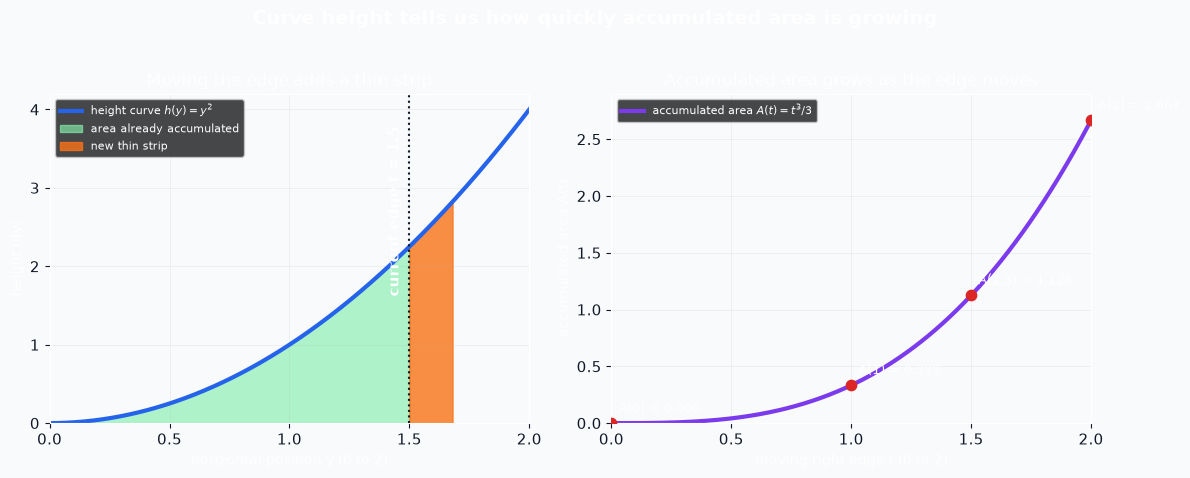

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Show how moving the right boundary adds one thin strip.
t = 1.5
strip_width = 0.18
y = np.linspace(0, 2, 600)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), facecolor="#f8fafc")
for ax in axes:
    ax.set_facecolor("#f8fafc")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="both", labelsize=11, colors="#111827")

axes[0].plot(y, y**2, color="#2563eb", linewidth=3, label=r"height curve $h(y)=y^2$")
inside = y <= t
axes[0].fill_between(y[inside], 0, y[inside]**2, color="#86efac", alpha=0.65,
                     label="area already accumulated")
axes[0].fill_between([t, t + strip_width], [0, 0], [t**2, (t + strip_width)**2],
                     color="#f97316", alpha=0.8, label="new thin strip")
axes[0].axvline(t, color="#111827", linestyle=":", linewidth=1.5)
axes[0].text(t - 0.03, 2.7, "current edge t = 1.5", rotation=90,
             ha="right", va="center", fontsize=11, fontweight="bold")
axes[0].set(title="Moving the edge adds a thin strip",
            xlabel="horizontal position y (0 to 2)", ylabel="height h(y)",
            xlim=(0, 2), ylim=(0, 4.2))
axes[0].set_xticks([0, 0.5, 1.0, 1.5, 2.0]); axes[0].set_yticks([0, 1, 2, 3, 4])
axes[0].legend(loc="upper left", fontsize=8)

# The accumulated area from 0 to t is A(t) = t^3 / 3.
t_values = np.linspace(0, 2, 600)
area_values = t_values**3 / 3
axes[1].plot(t_values, area_values, color="#7c3aed", linewidth=3,
             label=r"accumulated area $A(t)=t^3/3$")
marked_t = np.array([0.0, 1.0, 1.5, 2.0])
marked_area = marked_t**3 / 3
axes[1].scatter(marked_t, marked_area, color="#dc2626", s=55, zorder=3)
for x_value, area_value in zip(marked_t, marked_area):
    axes[1].annotate(f"A({x_value:g}) = {area_value:.3f}", (x_value, area_value),
                     xytext=(5, 8), textcoords="offset points", fontsize=9)
axes[1].set(title="Accumulated area grows as the edge moves",
            xlabel="moving right edge t (0 to 2)", ylabel="accumulated area A(t)",
            xlim=(0, 2), ylim=(0, 2.9))
axes[1].set_xticks([0, 0.5, 1.0, 1.5, 2.0]); axes[1].set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
axes[1].legend(loc="upper left", fontsize=8)

fig.suptitle("Curve height tells us how quickly accumulated area is growing", y=1.03,
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


### 1.8 Derivative and antiderivative, one idea at a time

A **derivative** measures how quickly one quantity changes when its input changes.

For example, if $A(t)$ means “area accumulated from $0$ to the moving edge $t$,” then its derivative tells us how quickly that area grows as $t$ moves.

The thin-strip picture tells us

$$
\text{rate at which area grows}=\text{current curve height}.
$$

In symbols:

$$
A'(t)=h(t).
$$

The prime mark in $A'(t)$ means “the derivative of $A$.”

An **antiderivative** asks the reverse question:

> If the rate of change is $h(t)$, which function $A(t)$ has that rate of change?

So differentiation and antidifferentiation point in opposite directions:

$$
A(t)
\xrightarrow{\text{differentiate}}
h(t),
$$

$$
h(t)
\xrightarrow{\text{find an antiderivative}}
A(t).
$$

For integration, we start with the height function and search for an area function whose derivative gives that height.


### 1.9 Why did the earlier notation use lowercase $g$ and uppercase $G$?

There is no mathematical requirement to use those letters.

A common calculus convention is:

- lowercase $g(y)$: the original function being integrated;
- uppercase $G(y)$: an antiderivative of $g(y)$.

The similar letters are intended to remind us that the functions are related, but they can be confusing when the idea is new.

In this notebook, we will use more meaningful letters for this example:

- $h(y)$ means the **height** of the original curve;
- $A(y)$ means the **accumulated area formula**.

Thus,

$$
h(y)=y^2
$$

and

$$
A(y)=\frac{y^3}{3}.
$$

The important relationship is not capitalization. It is

$$
A'(y)=h(y).
$$

We could rename the functions without changing the mathematics.


### 1.10 Calculate the exact value slowly

We want to calculate

$$
\int_0^2 y^2\,dy.
$$

Our height function is

$$
h(y)=y^2.
$$

We need an accumulated-area formula whose derivative is $y^2$. That formula is

$$
A(y)=\frac{y^3}{3}.
$$

We can check it: the derivative of $y^3$ is $3y^2$, so

$$
A'(y)
=\frac{3y^2}{3}
=y^2
=h(y).
$$

Once we know the correct area formula, the definite integral is

$$
\text{area from }0\text{ to }2
=A(2)-A(0).
$$

Evaluate the upper endpoint:

$$
A(2)=\frac{2^3}{3}=\frac{8}{3}.
$$

Evaluate the lower endpoint:

$$
A(0)=\frac{0^3}{3}=0.
$$

Subtract:

$$
\begin{aligned}
\int_0^2 y^2\,dy
&=A(2)-A(0)\
&=\frac{8}{3}-0\
&=\frac{8}{3}\
&\approx2.6667.
\end{aligned}
$$

The exact answer is $8/3$. The decimal $2.6667$ is only a rounded display of that exact fraction.

The rectangles explain what this number means. The antiderivative gives us the exact number without manually adding infinitely many rectangles.


### 1.11 What does the number $8/3$ represent?

For the graph $g(y)=y^2$ between $y=0$ and $y=2$,

$$
\int_0^2 y^2\,dy=\frac{8}{3}\approx2.6667
$$

is the exact accumulated area between the curve and the horizontal axis.

The meaning and units depend on what the axes represent:

- If both horizontal position and vertical height are measured in meters, the result is $2.6667$ square meters.
- If the vertical height is a probability density, the area over an interval is a probability.
- If the height is $q(y)[-\log p(y)]$, the accumulated number is average model surprise—the cross-entropy.

Thus, an integral always performs continuous accumulation, but the resulting number is not always a physical area. Geometric area is the picture that explains the calculation; the application determines what that accumulated number means.


### 1.12 What do bounds $-\infty$ and $\infty$ mean?

The expression

$$
\int_{-\infty}^{\infty}g(y)\,dy
$$

means accumulate over the entire real number line.

It does not automatically mean the result is infinite. A probability density can become extremely small in both tails, so the total accumulated area remains finite.

For a normal probability density,

$$
\int_{-\infty}^{\infty}p(y)\,dy=1.
$$

The bounds say where to accumulate; they do not determine the final value by themselves.


## Topic 2 — Integrals as probability


### 2.1 Discrete probability adds bars; continuous probability adds area

For a discrete variable such as a class label, probabilities are separate bars:

$$
\sum_k p_k=1.
$$

For a continuous variable such as temperature, individual points have no width. Probability is assigned to intervals by area under a density curve:

$$
\Pr(a\leq Y\leq b)
=\int_a^b p(y)\,dy.
$$

The density $p(y)$ is a height. The probability of an interval is accumulated height times tiny widths across that interval.


### 2.2 Density at a point is not probability at a point

For continuous $Y$:

- $p(22)$ is a density height near temperature $22$;
- $\Pr(21\leq Y\leq23)$ is an area and therefore a probability.

The total area under a valid density is one:

$$
\int_{-\infty}^{\infty}p(y)\,dy=1.
$$

This is why Chapter 5 sometimes uses $\Pr(y\mid\theta)$ even though the continuous formula is technically a density.


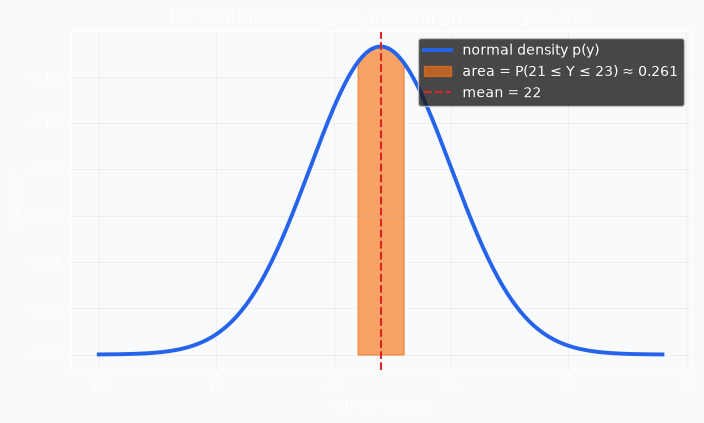

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

y = np.linspace(10, 34, 700)
mean, standard_deviation = 22, 3
density = norm.pdf(y, loc=mean, scale=standard_deviation)
inside = (y >= 21) & (y <= 23)
probability = norm.cdf(23, mean, standard_deviation) - norm.cdf(21, mean, standard_deviation)

fig, ax = plt.subplots(figsize=(8, 4.4), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
ax.plot(y, density, color="#2563eb", linewidth=2.8, label="normal density p(y)")
ax.fill_between(y[inside], density[inside], color="#f97316", alpha=0.65,
                label=f"area = P(21 ≤ Y ≤ 23) ≈ {probability:.3f}")
ax.axvline(22, color="#dc2626", linestyle="--", label="mean = 22")
ax.set(title="For continuous targets, interval probability is area",
       xlabel="Temperature y", ylabel="Density")
ax.legend(); ax.grid(alpha=0.2)
plt.show()


### 2.3 Probability-weighted averages

For separate outcomes, a probability-weighted average of values $g_j$ is

$$
\sum_j q_jg_j.
$$

For continuously varying outcomes, the corresponding weighted average is

$$
\int q(y)g(y)\,dy.
$$

Interpretation:

- $g(y)$ is the quantity being averaged;
- $q(y)$ says how much weight to place near $y$;
- the integral adds the weighted contributions over all possible $y$.

This is also called an **expectation**:

$$
\mathbb{E}_{Y\sim q}[g(Y)]
=\int q(y)g(y)\,dy.
$$


### 2.4 A concrete expectation example

Suppose $g(y)=y$ itself. Then

$$
\int q(y)y\,dy
$$

is the mean of the continuous distribution $q$.

If $g(y)=y^2$, then

$$
\int q(y)y^2\,dy
$$

is the probability-weighted average of squared values.

In cross-entropy, the quantity being averaged will be

$$
g(y)=-\log p(y).
$$

Therefore, cross-entropy is the $q$-weighted average of the model's negative-log score.


## Topic 3 — Logarithms, surprise, and entropy


### 3.1 What does the logarithm do here?

The logarithm is the inverse of the exponential:

$$
\log(\exp z)=z.
$$

Section 5.7 mainly relies on these rules:

$$
\log(ab)=\log a+\log b,
$$

$$
\log\left(\frac{a}{b}\right)=\log a-\log b.
$$

The logarithm converts products of likelihoods into sums. The negative sign then turns high model probability into low loss and low model probability into high loss.


### 3.2 Negative log probability is model surprise

Define surprise as

$$
s(y)=-\log p(y).
$$

| Model score at the observation | Surprise |
|---:|---:|
| $0.90$ | About $0.11$ |
| $0.50$ | About $0.69$ |
| $0.10$ | About $2.30$ |
| $0.01$ | About $4.61$ |

A model is penalized heavily when it assigns a very small score to something that actually occurs.


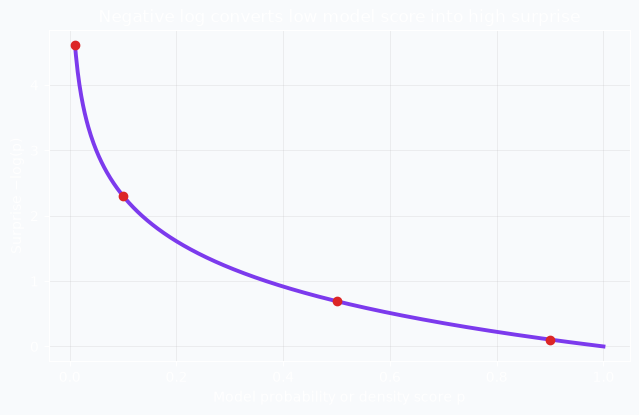

In [6]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.01, 1.0, 600)
surprise = -np.log(p)

fig, ax = plt.subplots(figsize=(7.5, 4.3), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
ax.plot(p, surprise, color="#7c3aed", linewidth=2.8)
ax.scatter([0.9, 0.5, 0.1, 0.01], -np.log([0.9, 0.5, 0.1, 0.01]), color="#dc2626", zorder=3)
ax.set(title="Negative log converts low model score into high surprise",
       xlabel="Model probability or density score p", ylabel="Surprise −log(p)")
ax.grid(alpha=0.25)
plt.show()


### 3.3 Entropy averages a distribution's own surprise

For a discrete distribution $q$, entropy is

$$
H(q)=-\sum_j q_j\log q_j.
$$

For a continuous density, the analogous expression is

$$
H(q)=-\int q(y)\log q(y)\,dy.
$$

Read the continuous version as:

> Average $-\log q(y)$ using $q(y)$ itself as the weighting distribution.

Entropy describes uncertainty intrinsic to $q$. In Section 5.7, $q$ represents the observed data distribution and remains fixed while the model changes.


## Topic 4 — Cross-entropy compares data $q$ with model $p$


### 4.1 Keep the two distributions separate

| Distribution | Role | Changes during model training? |
|---|---|---|
| $q(y)$ | Where real or empirical data occur | No |
| $p(y)$ | Where the model predicts targets should occur | Yes |

Cross-entropy uses $q$ for weighting but uses $p$ inside the surprise:

$$
H(q,p)
=-\int q(y)\log p(y)\,dy.
$$

Read it as:

> Average the model's surprise $-\log p(y)$ over values that occur according to the real-data distribution $q(y)$.


### 4.2 First see cross-entropy as an ordinary sum

Suppose the data frequencies and model probabilities are

| Class | $q_k$ | $p_k$ |
|---|---:|---:|
| Cat | $0.70$ | $0.50$ |
| Dog | $0.20$ | $0.30$ |
| Bird | $0.10$ | $0.20$ |

Discrete cross-entropy is

$$
H(q,p)
=-\sum_k q_k\log p_k.
$$

Substitute the table values:

$$
H(q,p)
=-[0.70\log0.50+0.20\log0.30+0.10\log0.20].
$$

Each class's model surprise is weighted by how frequently that class occurs in reality.


### 4.3 Replace the class sum with a continuous integral

For continuous values, replace

$$
-\sum_k q_k\log p_k
$$

with

$$
-\int_{-\infty}^{\infty}q(y)\log p(y)\,dy.
$$

Nothing conceptual changed:

| Discrete | Continuous |
|---|---|
| Visit every class $k$ | Visit every possible value $y$ |
| Weight by $q_k$ | Weight by density $q(y)$ and tiny width $dy$ |
| Surprise $-\log p_k$ | Surprise $-\log p(y)$ |
| Add with $\sum$ | Accumulate with $\int$ |


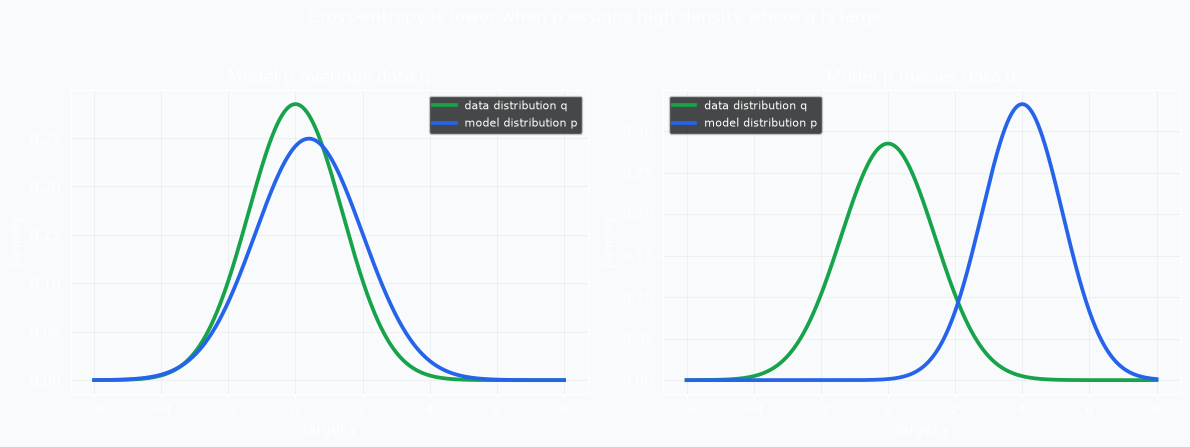

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

y = np.linspace(-6, 8, 800)
q = norm.pdf(y, loc=0, scale=1.4)
p_good = norm.pdf(y, loc=0.4, scale=1.6)
p_bad = norm.pdf(y, loc=4.0, scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), facecolor="#f8fafc")
for ax in axes: ax.set_facecolor("#f8fafc")
for ax, model, title in [(axes[0], p_good, "Model p overlaps data q"), (axes[1], p_bad, "Model p misses data q")]:
    ax.plot(y, q, color="#16a34a", linewidth=2.7, label="data distribution q")
    ax.plot(y, model, color="#2563eb", linewidth=2.7, label="model distribution p")
    ax.set(title=title, xlabel="Target y", ylabel="Density")
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
fig.suptitle("Cross-entropy is lower when p assigns high density where q is large", y=1.03)
fig.tight_layout()
plt.show()


### 4.4 KL divergence separates fixed data uncertainty from model mismatch

The book defines

$$
D_{KL}(q\Vert p)
=\int q(y)\log q(y)\,dy
-\int q(y)\log p(y)\,dy.
$$

Using entropy and cross-entropy notation:

$$
D_{KL}(q\Vert p)=H(q,p)-H(q).
$$

- $H(q)$ depends only on the data distribution.
- $H(q,p)$ depends on the model distribution $p$.

Training changes $p$ but not $q$. Therefore, minimizing KL divergence over the model parameters is equivalent to minimizing cross-entropy.

You do not need to calculate KL divergence for this derivation. You only need to identify which term can change.


## Topic 5 — Empirical data and Dirac selector spikes


### 5.1 A dataset contains finitely many observed target values

Suppose the training targets are

$$
y_1=-4,
\quad y_2=-2,
\quad y_3=1,
\quad y_4=3.
$$

The empirical distribution should place equal weight at these four observed locations.

A histogram approximates this with bins. Equation 5.28 instead uses idealized point masses called Dirac deltas, which let the book represent exact observed locations inside an integral.


### 5.2 A Dirac delta is not an ordinary function

The notation

$$
\delta(y-y_i)
$$

represents an idealized spike centered at $y_i$.

Its intuitive properties are:

- it contributes nothing away from $y_i$;
- it has total area one;
- inside an integral, it selects the integrand's value at $y_i$.

The selection property is

$$
\int_{-\infty}^{\infty}
\delta(y-y_i)g(y)\,dy
=g(y_i).
$$

For this chapter, treat the Dirac delta as an **integral selector**, not as a finite-height curve.


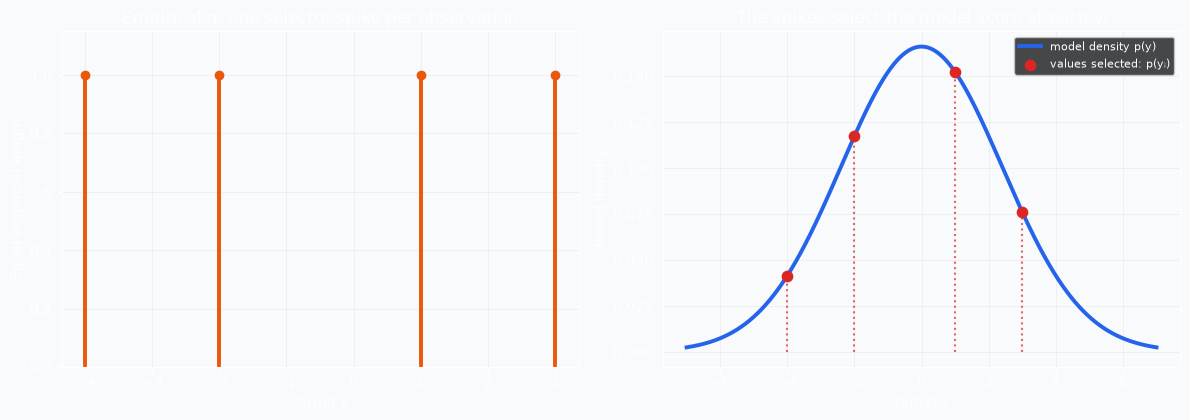

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

observations = np.array([-4.0, -2.0, 1.0, 3.0])
y = np.linspace(-7, 7, 700)
p = norm.pdf(y, loc=0, scale=2.4)
p_at_observations = norm.pdf(observations, loc=0, scale=2.4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), facecolor="#f8fafc")
for ax in axes: ax.set_facecolor("#f8fafc")
axes[0].vlines(observations, 0, 1, color="#ea580c", linewidth=2.8)
axes[0].scatter(observations, np.ones_like(observations), color="#ea580c", zorder=3)
axes[0].set(title="Empirical q: one selector spike per observation",
            xlabel="Target y", ylabel="Equal empirical weight", ylim=(0, 1.15))

axes[1].plot(y, p, color="#2563eb", linewidth=2.8, label="model density p(y)")
axes[1].scatter(observations, p_at_observations, color="#dc2626", s=55,
                label="values selected: p(yᵢ)", zorder=3)
for x, score in zip(observations, p_at_observations):
    axes[1].vlines(x, 0, score, color="#dc2626", linestyle=":", alpha=0.7)
axes[1].set(title="The spikes select the model score at each yᵢ",
            xlabel="Target y", ylabel="Model density")
axes[1].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


### 5.3 Equation 5.28 builds $q$ from all selector spikes

For $I$ observations, the empirical distribution is

$$
q(y)
=\frac{1}{I}\sum_{i=1}^{I}\delta(y-y_i).
$$

Translate it piece by piece:

| Part | Meaning |
|---|---|
| $i$ | Which training observation? |
| $y_i$ | Observed target for example $i$ |
| $\delta(y-y_i)$ | Selector spike at observation $y_i$ |
| $\sum_i$ | Include every observation |
| $1/I$ | Give every observation equal weight |

The total empirical weight is one.


## Topic 6 — Derive Equations 5.27–5.31 line by line


### 6.1 Equation 5.27: start from KL divergence

The equation is

$$
D_{KL}(q\Vert p)
=\underbrace{\int q(y)\log q(y)\,dy}_{\text{depends only on fixed data }q}
-\underbrace{\int q(y)\log p(y)\,dy}_{\text{depends on model }p}.
$$

When optimizing the model, the first term cannot change. The second term can change.

Therefore, minimizing KL divergence with respect to the model is equivalent to minimizing

$$
-\int q(y)\log p(y)\,dy,
$$

which is cross-entropy.


### 6.2 Equation 5.28: substitute the empirical data distribution

Use

$$
q(y)=\frac{1}{I}\sum_{i=1}^{I}\delta(y-y_i).
$$

Substitute it into cross-entropy:

$$
-\int
\left[
\frac{1}{I}\sum_{i=1}^{I}\delta(y-y_i)
\right]
\log p(y)\,dy.
$$

The square brackets are the empirical distribution. The remaining factor $\log p(y)$ comes from model surprise.


### 6.3 Move the finite sum and constant outside the integral

Integration is linear, so constants and finite sums can move outside:

$$
-\frac{1}{I}\sum_{i=1}^{I}
\int
\delta(y-y_i)\log p(y)\,dy.
$$

Now there is one integral for each training observation.

Each integral contains a selector spike centered at its own observed target $y_i$.


### 6.4 Apply the Dirac selection property

Recall

$$
\int\delta(y-y_i)g(y)\,dy=g(y_i).
$$

Set

$$
g(y)=\log p(y).
$$

Then

$$
\int\delta(y-y_i)\log p(y)\,dy
=\log p(y_i).
$$

Apply this to every observation:

$$
-\frac{1}{I}\sum_{i=1}^{I}\log p(y_i).
$$

The integral has disappeared. The result is average negative log-likelihood.


### 6.5 Why Equation 5.30 removes $1/I$

The average NLL is

$$
-\frac{1}{I}\sum_{i=1}^{I}\log p(y_i).
$$

The summed NLL is

$$
-\sum_{i=1}^{I}\log p(y_i).
$$

The factor $1/I$ is fixed and positive. Multiplying the entire objective by $I$ changes its numerical scale but does not move the minimum.

Thus, both objectives fit the same model parameters, although their reported numerical values differ.


### 6.6 Equation 5.31 inserts the neural network

For input $x_i$, the network predicts distribution parameters:

$$
\theta_i=f[x_i,\phi].
$$

The model density or probability at the observed target is

$$
\Pr(y_i\mid f[x_i,\phi]).
$$

Therefore,

$$
\mathcal{L}[\phi]
=-\sum_{i=1}^{I}
\log\Pr(y_i\mid f[x_i,\phi]).
$$

This is exactly the negative log-likelihood criterion developed earlier in Chapter 5.

Section 5.7 has shown that minimizing empirical cross-entropy, minimizing KL divergence to the empirical distribution, and minimizing NLL all select the same model parameters.


## Topic 7 — A complete numerical example


### 7.1 Observe targets and evaluate one model density

Suppose the observed continuous targets are

$$
y_1=-2,
\quad y_2=-1,
\quad y_3=0,
\quad y_4=1,
\quad y_5=2.
$$

The model predicts a normal density with mean $0$ and standard deviation $1.5$.

For each observed target:

1. evaluate the model density $p(y_i)$;
2. compute surprise $-\log p(y_i)$;
3. average the surprises.

That average is simultaneously empirical cross-entropy and average NLL.


 observed yᵢ   density p(yᵢ)   surprise −log p(yᵢ)
       -2.0         0.10934              2.21329
       -1.0         0.21297              1.54663
        0.0         0.26596              1.32440
        1.0         0.21297              1.54663
        2.0         0.10934              2.21329

Average empirical cross-entropy / NLL = 1.76885


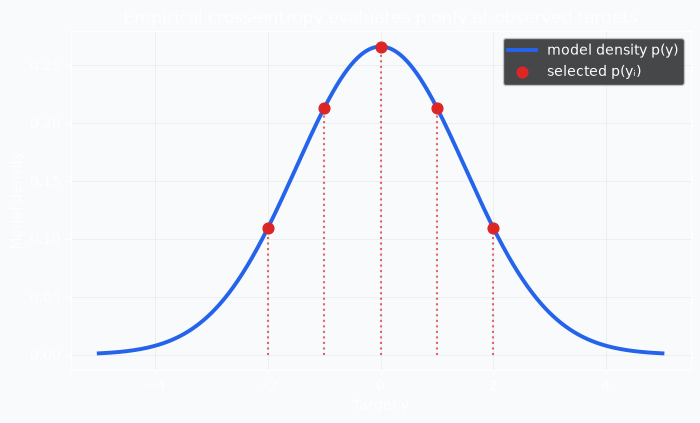

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

observations = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
mean, standard_deviation = 0.0, 1.5
scores = norm.pdf(observations, loc=mean, scale=standard_deviation)
losses = -np.log(scores)
average_loss = np.mean(losses)

print(" observed yᵢ   density p(yᵢ)   surprise −log p(yᵢ)")
for y_i, score, loss in zip(observations, scores, losses):
    print(f" {y_i:10.1f}   {score:13.5f}   {loss:18.5f}")
print()
print(f"Average empirical cross-entropy / NLL = {average_loss:.5f}")

y = np.linspace(-5, 5, 700)
density = norm.pdf(y, loc=mean, scale=standard_deviation)
fig, ax = plt.subplots(figsize=(8, 4.4), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
ax.plot(y, density, color="#2563eb", linewidth=2.8, label="model density p(y)")
ax.scatter(observations, scores, color="#dc2626", s=60, zorder=3, label="selected p(yᵢ)")
for x, score in zip(observations, scores):
    ax.vlines(x, 0, score, color="#dc2626", linestyle=":", alpha=0.7)
ax.set(title="Empirical cross-entropy evaluates p only at observed targets",
       xlabel="Target y", ylabel="Model density")
ax.legend(); ax.grid(alpha=0.2)
plt.show()


## Topic 8 — Consolidation


### 8.1 The complete story without symbols

1. An integral is the limit of adding many thin rectangle contributions.
2. A probability density uses area to assign probability to continuous intervals.
3. An integral weighted by a density is a continuous weighted average.
4. Negative log model density measures how surprised the model is at an observation.
5. Cross-entropy averages model surprise using the real-data distribution as weights.
6. KL divergence equals cross-entropy minus a term depending only on the fixed data distribution.
7. The empirical distribution places equal selector spikes at observed training targets.
8. Each selector spike makes the integral evaluate model surprise at one observation.
9. The integral therefore becomes an average over observed negative log-likelihoods.
10. Removing the fixed averaging factor gives summed NLL.


### 8.2 The formula roadmap

$$
D_{KL}(q\Vert p)
=\int q\log q-\int q\log p
$$

$$
\Downarrow
\quad \text{first term fixed while optimizing }p
$$

$$
H(q,p)=-\int q(y)\log p(y)\,dy
$$

$$
\Downarrow
\quad q(y)=\frac{1}{I}\sum_i\delta(y-y_i)
$$

$$
-\frac{1}{I}\sum_i
\int\delta(y-y_i)\log p(y)\,dy
$$

$$
\Downarrow
\quad \text{selector property}
$$

$$
-\frac{1}{I}\sum_i\log p(y_i)
$$

$$
\Downarrow
\quad \text{remove fixed positive scale }1/I
$$

$$
-\sum_i\log\Pr(y_i\mid f[x_i,\phi]).
$$


### 8.3 What is good enough for now?

You understand Section 5.7 sufficiently if you can explain:

- why an integral is a continuous accumulation;
- why probability for continuous values is area under a density;
- why $\int q(y)g(y)dy$ is a $q$-weighted average of $g$;
- why cross-entropy averages $-\log p(y)$ using $q(y)$;
- why the data-only KL term does not affect model optimization;
- why empirical data are represented by equal selector spikes;
- how the selector property converts the integral into a sum over observations;
- why the final expression is NLL.

You are not expected to integrate the normal curve by hand or prove Dirac delta theory.


### 8.4 Checks with answers

**Check 1:** What does $dy$ contribute to the integral picture?

**Answer:** It represents a tiny width along the $y$ axis, so integrand height times tiny width gives one tiny accumulated contribution.

**Check 2:** In $-\int q(y)\log p(y)dy$, which distribution supplies the weights?

**Answer:** $q(y)$, the real-data distribution.

**Check 3:** Which distribution supplies the surprise?

**Answer:** $p(y)$, through $-\log p(y)$.

**Check 4:** Why does the empirical integral become a finite sum?

**Answer:** The empirical $q$ consists of Dirac selector spikes, and each spike selects the model log score at one observed target.
